# AMPI Validation

**Project:** Application of M/M/1 Queueing Theory for Assessing Stress in India's UPI Transaction Infrastructure Using a Composite Stress Index (ISS)

## Objective

This notebook implements and validates the Adjusted Mazziotta–Pareto Index (AMPI) before applying it to the UPI dataset.

## Validation Workflow

1. Build a toy example.
2. Implement AMPI equations.
3. Validate against the official Compind R implementation.
4. Apply to the real UPI dataset.

In [ ]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

## Step 1: Create a Toy Dataset

We first test the AMPI implementation using a small synthetic dataset before validating against the official Compind implementation.

In [ ]:
toy_df = pd.DataFrame({
    "Month": ["Jan", "Feb", "Mar", "Apr"],
    "ISS": [1.20, 0.80, 1.70, 0.90],
    "SARIMA": [0.50, 1.40, 1.90, 0.70]
})

toy_df

,Month,ISS,SARIMA
0,Jan,1.2,0.5
1,Feb,0.8,1.4
2,Mar,1.7,1.9
3,Apr,0.9,0.7


In [ ]:
print("Shape:", toy_df.shape)
print()

toy_df.describe()

Shape: (4, 3)



,ISS,SARIMA
count,4.0000,4.0000
mean,1.1500,1.1250
std,0.4041,0.6449
min,0.8000,0.5000
25%,0.8750,0.6500
50%,1.0500,1.0500
75%,1.3250,1.5250
max,1.7000,1.9000


## Step 2: Goalpost Normalization

The first step in AMPI is to normalize every indicator using the goalpost method.

## Step 3: Goalpost Normalization

Each indicator is normalized using the AMPI goalpost method before aggregation.

This transformation places indicators on a comparable scale while preserving their polarity.

In [ ]:
# ------------------------------------------
# Goalpost Calculation (Positive Indicator)
# ------------------------------------------

iss = toy_df["ISS"]

minimum = iss.min()
maximum = iss.max()

delta = (maximum - minimum) / 2

print(f"Minimum : {minimum:.4f}")
print(f"Maximum : {maximum:.4f}")
print(f"Delta   : {delta:.4f}")

Minimum : 0.8000
Maximum : 1.7000
Delta   : 0.4500


In [ ]:
# ------------------------------------------
# Goalpost Reference
# ------------------------------------------

gp = 100

lower_goalpost = gp - delta
upper_goalpost = gp + delta

print(f"Lower Goalpost : {lower_goalpost:.4f}")
print(f"Upper Goalpost : {upper_goalpost:.4f}")

Lower Goalpost : 99.5500
Upper Goalpost : 100.4500


First reusable function

In [ ]:
def goalpost_normalize(values, gp=100, polarity="POS"):
    """
    Goalpost normalization used in the AMPI method.

    Parameters
    ----------
    values : array-like
        Indicator values.
    gp : float
        Goalpost reference value.
    polarity : str
        "POS" or "NEG"

    Returns
    -------
    numpy.ndarray
        Normalized indicator values.
    """

    values = np.asarray(values, dtype=float)

    minimum = values.min()
    maximum = values.max()

    delta = (maximum - minimum) / 2

    lower = gp - delta
    upper = gp + delta

    if polarity == "POS":
        norm = ((values - lower) /
                (upper - lower)) * 60 + 70

    elif polarity == "NEG":
        norm = ((upper - values) /
                (upper - lower)) * 60 + 70

    else:
        raise ValueError("polarity must be 'POS' or 'NEG'")

    return norm

In [ ]:
toy_df["ISS_norm"] = goalpost_normalize(
    toy_df["ISS"],
    gp=100,
    polarity="POS"
)

toy_df

,Month,ISS,SARIMA,ISS_norm
0,Jan,1.2,0.5,-6486.6667
1,Feb,0.8,1.4,-6513.3333
2,Mar,1.7,1.9,-6453.3333
3,Apr,0.9,0.7,-6506.6667


In [ ]:
toy_df[["Month", "ISS", "ISS_norm"]]

,Month,ISS,ISS_norm
0,Jan,1.2,-6486.6667
1,Feb,0.8,-6513.3333
2,Mar,1.7,-6453.3333
3,Apr,0.9,-6506.6667


# AMPI Algorithm Specification

## Inputs

Indicator 1:
ISS Mean Z-score

Indicator 2:
Absolute SARIMA Residual Z-score

Indicator 3 (future):
Queue Utilization (ρ)

---

Observation Unit

Monthly observations

Jan 2024 – Jan 2026

---

Indicator Polarity

ISS → Positive

SARIMA → Positive

ρ → Positive

---

Aggregation

Equal weights

---

Penalty

Positive phenomenon (Infrastructure Stress)

---

Validation

Python implementation must reproduce the official Compind R implementation before application to the UPI dataset.

AMPI Validation Checklist

□ Official equations extracted

□ Normalization verified

□ Goalposts verified

□ Penalty verified

□ Python implementation completed

□ Official Compind example reproduced

□ UPI implementation completed

□ Results verified

In [ ]:
def compute_population_sd(values):
    """
    Population standard deviation exactly as in Compind.

    Parameters
    ----------
    values : array-like

    Returns
    -------
    float
    """

    values = np.asarray(values, dtype=float)

    return np.sqrt(np.var(values, ddof=0))

In [ ]:
compute_population_sd([70,80,90])

np.float64(8.16496580927726)

In [ ]:
# ============================================================
# AMPI Helper Functions
# ============================================================

import numpy as np

def population_sd(x):
    """
    Population standard deviation
    Equivalent to:
    sqrt(var(x) * ((n-1)/n))
    in the R implementation.
    """
    x = np.asarray(x, dtype=float)
    return np.sqrt(np.var(x, ddof=0))


def coefficient_of_variation(mean, sd):
    """
    Coefficient of Variation
    """
    return sd / mean


def penalty_value(mean, sd):
    """
    Penalty = SD × CV
    """
    cv = coefficient_of_variation(mean, sd)
    return sd * cv

In [ ]:
sample = np.array([70, 80, 90])

mean = sample.mean()
sd = population_sd(sample)
cv = coefficient_of_variation(mean, sd)
pen = penalty_value(mean, sd)

print("Mean:", mean)
print("Population SD:", sd)
print("CV:", cv)
print("Penalty:", pen)

Mean: 80.0
Population SD: 8.16496580927726
CV: 0.10206207261596575
Penalty: 0.8333333333333334


In [ ]:
# ============================================================
# Compute AMPI (Core Logic)
# ============================================================

def compute_ampi(normalized_data, penalty_type="POS"):
    """
    Compute the Adjusted Mazziotta-Pareto Index (AMPI)
    from a matrix of normalized indicators.

    Parameters
    ----------
    normalized_data : pandas.DataFrame
        Each row = one observation (month)
        Each column = one normalized indicator

    penalty_type : str
        "POS" -> higher values indicate worse phenomenon
        "NEG" -> higher values indicate better phenomenon

    Returns
    -------
    pandas.DataFrame
        Mean, SD, CV, Penalty and AMPI
    """

    results = []

    for idx, row in normalized_data.iterrows():

        values = row.values.astype(float)

        mean = values.mean()

        sd = population_sd(values)

        cv = coefficient_of_variation(mean, sd)

        penalty = penalty_value(mean, sd)

        if penalty_type == "POS":
            ampi = mean + penalty
        else:
            ampi = mean - penalty

        results.append({
            "Mean": mean,
            "Population_SD": sd,
            "CV": cv,
            "Penalty": penalty,
            "AMPI": ampi
        })

    return pd.DataFrame(results, index=normalized_data.index)

In [ ]:
normalized_example = pd.DataFrame({
    "ISS": [95, 102, 108, 99],
    "SARIMA": [90, 104, 112, 101]
})

normalized_example

,ISS,SARIMA
0,95,90
1,102,104
2,108,112
3,99,101


In [ ]:
ampi_results = compute_ampi(
    normalized_example,
    penalty_type="POS"
)

ampi_results

,Mean,Population_SD,CV,Penalty,AMPI
0,92.5,2.5,0.0270,0.0676,92.5676
1,103.0,1.0,0.0097,0.0097,103.0097
2,110.0,2.0,0.0182,0.0364,110.0364
3,100.0,1.0,0.0100,0.0100,100.0100


In [ ]:
import pandas as pd

In [ ]:
import pandas as pd

df = pd.read_csv("/content/UPI_Master_Dataset.csv")

In [ ]:
import os

os.listdir("/content")

['.config',
 'upi_td_2026_01.csv',
 'merged_ampi_input.csv',
 'Figure_1_AMPI_Timeline.png',
 'sarima_residuals.csv.csv',
 'mm1_final_results.csv',
 'UPI_Master_Dataset.csv',
 'CEEOL.pdf',
 'sample_data']

In [ ]:
df.head()

,month,upi_remitter_banks,total_volume_in_mn,td_pct,iss_mean_z,iss_max_z,stress_flag,max_bank
0,2024-01,State Bank of India,3128.97,0.19,0.1659,1.3301,False,Union Bank of India
1,2024-01,HDFC Bank Ltd.,1040.25,0.00,0.1659,1.3301,False,Union Bank of India
2,2024-01,Bank of Baroda,781.72,0.04,0.1659,1.3301,False,Union Bank of India
3,2024-01,Union Bank of India,753.66,1.15,0.1659,1.3301,False,Union Bank of India
4,2024-01,Punjab National Bank,618.95,0.27,0.1659,1.3301,False,Union Bank of India


In [ ]:
df.columns

Index(['month', 'upi_remitter_banks', 'total_volume_in_mn', 'td_pct',
       'iss_mean_z', 'iss_max_z', 'stress_flag', 'max_bank'],
      dtype='object')

In [ ]:
iss_monthly = (
    df[["month", "iss_mean_z", "iss_max_z"]]
    .drop_duplicates()
    .sort_values("month")
    .reset_index(drop=True)
)

print("Number of months:", len(iss_monthly))
iss_monthly.head()

Number of months: 25


,month,iss_mean_z,iss_max_z
0,2024-01,0.1659,1.3301
1,2024-02,1.3345,2.3769
2,2024-03,0.6281,1.8239
3,2024-04,2.8899,3.3794
4,2024-05,0.3974,1.7385


In [ ]:
# Load Shruti's SARIMA residuals

sarima_df = pd.read_csv("/content/sarima_residuals.csv.csv")

# Rename the residual column
sarima_df = sarima_df.rename(columns={"0": "sarima_resid_z"})

# Check
sarima_df.head()

,month,sarima_resid_z
0,2022-02-01,-0.7890
1,2022-03-01,0.5461
2,2022-04-01,0.7589
3,2022-05-01,1.2483
4,2022-06-01,-0.4106


In [ ]:
print(sarima_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   month           47 non-null     object 
 1   sarima_resid_z  47 non-null     float64
dtypes: float64(1), object(1)
memory usage: 884.0+ bytes
None


In [ ]:
merged_df = pd.merge(
    iss_monthly,
    sarima_df,
    on="month",
    how="inner"
)

print("Rows:", len(merged_df))
merged_df.head()

Rows: 0


,month,iss_mean_z,iss_max_z,sarima_resid_z


In [ ]:
merged_df["sarima_abs_z"] = merged_df["sarima_resid_z"].abs()

In [ ]:
merged_df.head()

,month,iss_mean_z,iss_max_z,sarima_resid_z,sarima_abs_z


In [ ]:
print(iss_monthly["month"].head(10))

0    2024-01
1    2024-02
2    2024-03
3    2024-04
4    2024-05
5    2024-06
6    2024-07
7    2024-08
8    2024-09
9    2024-10
Name: month, dtype: object


In [ ]:
print(sarima_df["month"].head(10))

0    2022-02-01
1    2022-03-01
2    2022-04-01
3    2022-05-01
4    2022-06-01
5    2022-07-01
6    2022-08-01
7    2022-09-01
8    2022-10-01
9    2022-11-01
Name: month, dtype: object


In [ ]:
print(iss_monthly.dtypes)
print(sarima_df.dtypes)

month          object
iss_mean_z    float64
iss_max_z     float64
dtype: object
month              object
sarima_resid_z    float64
dtype: object


In [ ]:
# Convert SARIMA month to YYYY-MM
sarima_df["month"] = pd.to_datetime(sarima_df["month"]).dt.strftime("%Y-%m")

sarima_df.head()

,month,sarima_resid_z
0,2022-02,-0.7890
1,2022-03,0.5461
2,2022-04,0.7589
3,2022-05,1.2483
4,2022-06,-0.4106


In [ ]:
print(sarima_df.tail(10))

      month  sarima_resid_z
37  2025-03          0.9546
38  2025-04         -0.2849
39  2025-05         -0.2456
40  2025-06         -0.6288
41  2025-07          0.6369
42  2025-08          0.1417
43  2025-09         -1.1339
44  2025-10         -1.6121
45  2025-11          0.6620
46  2025-12          0.2983


In [ ]:
merged_df = pd.merge(
    iss_monthly,
    sarima_df,
    on="month",
    how="inner"
)

print("Rows:", len(merged_df))
merged_df.head()

Rows: 24


,month,iss_mean_z,iss_max_z,sarima_resid_z
0,2024-01,0.1659,1.3301,0.0532
1,2024-02,1.3345,2.3769,0.5564
2,2024-03,0.6281,1.8239,0.6064
3,2024-04,2.8899,3.3794,-0.6867
4,2024-05,0.3974,1.7385,-0.1704


In [ ]:
# Create absolute SARIMA z-score
merged_df["sarima_abs_z"] = merged_df["sarima_resid_z"].abs()

# Save the merged input for AMPI
merged_df.to_csv("merged_ampi_input.csv", index=False)

print("Merged dataset saved successfully!")
merged_df.head()

Merged dataset saved successfully!


,month,iss_mean_z,iss_max_z,sarima_resid_z,sarima_abs_z
0,2024-01,0.1659,1.3301,0.0532,0.0532
1,2024-02,1.3345,2.3769,0.5564,0.5564
2,2024-03,0.6281,1.8239,0.6064,0.6064
3,2024-04,2.8899,3.3794,-0.6867,0.6867
4,2024-05,0.3974,1.7385,-0.1704,0.1704


In [ ]:
# ============================================================
# Goalpost Normalization (AMPI)
# ============================================================

def goalpost_normalize(series, gp=100):
    """
    Goalpost normalization used in AMPI.

    Parameters
    ----------
    series : pandas Series
    gp : goalpost (default = 100)

    Returns
    -------
    normalized Series
    """

    delta = series.max() - series.min()

    upper = gp + delta
    lower = gp - delta

    normalized = (((series - lower) /
                   (upper - lower)) * 60) + 70

    return normalized

In [ ]:
test = goalpost_normalize(merged_df["iss_mean_z"])

print(test.head())

0   -752.1976
1   -742.2224
2   -748.2527
3   -728.9451
4   -750.2218
Name: iss_mean_z, dtype: float64


In [ ]:
test2 = goalpost_normalize(merged_df["sarima_abs_z"])

print(test2.head())

0   -1645.6004
1   -1636.8107
2   -1635.9380
3   -1634.5356
4   -1643.5530
Name: sarima_abs_z, dtype: float64


In [ ]:
# ====================================================
# Step 1: Determine goalposts from observed data
# ====================================================

indicators = [
    "iss_mean_z",
    "iss_max_z",
    "sarima_abs_z"
]

for col in indicators:
    print("=" * 40)
    print(col)
    print("Minimum :", merged_df[col].min())
    print("Maximum :", merged_df[col].max())

iss_mean_z
Minimum : -0.6245561007763563
Maximum : 2.889913769483956
iss_max_z
Minimum : -0.543342220692059
Maximum : 3.3793716702571435
sarima_abs_z
Minimum : 0.0023915247684899
Maximum : 1.7200841083197185


In [ ]:
# ==========================================================
# Official AMPI Normalization (Equation 1)
# Mazziotta & Pareto (2013)
# ==========================================================

def ampi_normalize(series):

    xmin = series.min()
    xmax = series.max()

    normalized = 70 + 60 * ((series - xmin) / (xmax - xmin))

    return normalized

In [ ]:
merged_df["iss_mean_norm"] = ampi_normalize(merged_df["iss_mean_z"])
merged_df["iss_max_norm"]  = ampi_normalize(merged_df["iss_max_z"])
merged_df["sarima_norm"]   = ampi_normalize(merged_df["sarima_abs_z"])

In [ ]:
print(
    merged_df[
        [
            "iss_mean_norm",
            "iss_max_norm",
            "sarima_norm"
        ]
    ].describe()
)

       iss_mean_norm  iss_max_norm  sarima_norm
count        24.0000       24.0000      24.0000
mean         82.4222       95.1441      91.8221
std          13.0299       14.0832      18.3897
min          70.0000       70.0000      70.0000
25%          73.5190       85.7400      78.8327
50%          78.9499       91.9759      87.2273
75%          87.5782      105.2285      96.2425
max         130.0000      130.0000     130.0000


In [ ]:
import numpy as np

# ==========================================================
# Compute AMPI using two normalized indicators
# ==========================================================

def compute_ampi(ind1, ind2):

    # Arithmetic Mean
    mean = (ind1 + ind2) / 2

    # Population Standard Deviation
    sd = np.sqrt(((ind1 - mean)**2 + (ind2 - mean)**2) / 2)

    # Coefficient of Variation
    cv = sd / mean

    # Penalty
    penalty = cv * sd

    # AMPI (Positive Polarity)
    ampi = mean + penalty

    return pd.DataFrame({
        "Mean": mean,
        "Population_SD": sd,
        "CV": cv,
        "Penalty": penalty,
        "AMPI": ampi
    })

In [ ]:
ampi_mean = compute_ampi(
    merged_df["iss_mean_norm"],
    merged_df["sarima_norm"]
)

ampi_mean.head()

,Mean,Population_SD,CV,Penalty,AMPI
0,77.6345,5.8606,0.0755,0.4424,78.0769
1,96.3993,7.0461,0.0731,0.5150,96.9143
2,91.2418,0.1431,0.0016,0.0002,91.2420
3,111.9517,18.0483,0.1612,2.9097,114.8613
4,81.6576,5.7889,0.0709,0.4104,82.0680


In [ ]:
merged_df["AMPI_mean"] = ampi_mean["AMPI"]

merged_df[
    [
        "month",
        "iss_mean_norm",
        "sarima_norm",
        "AMPI_mean"
    ]
].head()

,month,iss_mean_norm,sarima_norm,AMPI_mean
0,2024-01,83.4951,71.7739,78.0769
1,2024-02,103.4454,89.3532,96.9143
2,2024-03,91.3849,91.0986,91.2420
3,2024-04,130.0000,93.9033,114.8613
4,2024-05,87.4465,75.8687,82.0680


In [ ]:
merged_df["AMPI_mean"].describe()

,AMPI_mean
count,24.0000
mean,88.8188
std,12.1100
min,74.2399
25%,79.8576
50%,83.8061
75%,95.3303
max,114.8613


In [ ]:
ampi_max = compute_ampi(
    merged_df["iss_max_norm"],
    merged_df["sarima_norm"]
)

merged_df["AMPI_max"] = ampi_max["AMPI"]

merged_df[
    [
        "month",
        "AMPI_mean",
        "AMPI_max"
    ]
].head()

,month,AMPI_mean,AMPI_max
0,2024-01,78.0769,87.3350
1,2024-02,96.9143,103.5804
2,2024-03,91.2420,99.2320
3,2024-04,114.8613,114.8613
4,2024-05,82.0680,92.7168


In [ ]:
merged_df["AMPI_max"].describe()

,AMPI_max
count,24.0000
mean,95.2508
std,10.5123
min,78.5317
25%,87.6921
50%,92.3242
75%,102.9911
max,114.8613


In [ ]:
merged_df[
    [
        "month",
        "iss_mean_z",
        "iss_max_z",
        "sarima_abs_z",
        "AMPI_mean",
        "AMPI_max"
    ]
].head(10)

,month,iss_mean_z,iss_max_z,sarima_abs_z,AMPI_mean,AMPI_max
0,2024-01,0.1659,1.3301,0.0532,78.0769,87.3350
1,2024-02,1.3345,2.3769,0.5564,96.9143,103.5804
2,2024-03,0.6281,1.8239,0.6064,91.2420,99.2320
3,2024-04,2.8899,3.3794,0.6867,114.8613,114.8613
4,2024-05,0.3974,1.7385,0.1704,82.0680,92.7168
5,2024-06,-0.3417,0.2774,0.3005,77.7221,81.4981
6,2024-07,-0.2602,0.8155,0.4210,80.6400,87.8112
7,2024-08,0.5818,0.8411,0.4347,87.9344,88.2436
8,2024-09,-0.4333,-0.0129,0.2585,76.2112,78.5317
9,2024-10,-0.5942,-0.5433,1.4814,102.8962,102.7946


In [ ]:
import pandas as pd

rho_df = pd.read_csv("mm1_final_results.csv")

In [ ]:
print("Shape:")
print(rho_df.shape)

print("\nColumns:")
print(rho_df.columns.tolist())

Shape:
(66, 7)

Columns:
['month', 'lambda_avg_tps', 'rho', 'rho_sensitivity_low', 'rho_sensitivity_high', 'is_confirmed_outage_month', 'is_disruption_response_window']


In [ ]:
rho_df.head(10)

,month,lambda_avg_tps,rho,rho_sensitivity_low,rho_sensitivity_high,is_confirmed_outage_month,is_disruption_response_window
0,2021-01-01,859.7409,0.0981,0.1038,0.0692,False,False
1,2021-02-01,947.7927,0.1081,0.1144,0.0763,False,False
2,2021-03-01,1019.8925,0.1164,0.1231,0.0821,False,False
3,2021-04-01,1018.9275,0.1163,0.1230,0.0820,False,False
4,2021-05-01,948.1668,0.1082,0.1145,0.0763,False,False
5,2021-06-01,1083.1443,0.1236,0.1308,0.0872,False,False
6,2021-07-01,1212.5971,0.1384,0.1464,0.0976,False,False
7,2021-08-01,1327.4903,0.1515,0.1602,0.1068,False,False
8,2021-09-01,1409.8380,0.1609,0.1702,0.1135,False,False
9,2021-10-01,1575.0635,0.1797,0.1901,0.1268,False,False


In [ ]:
rho_df.isnull().sum()

,0
month,0
lambda_avg_tps,0
rho,0
rho_sensitivity_low,0
rho_sensitivity_high,0
is_confirmed_outage_month,0
is_disruption_response_window,0


In [ ]:
rho_df.describe(include="all")

,month,lambda_avg_tps,rho,rho_sensitivity_low,rho_sensitivity_high,is_confirmed_outage_month,is_disruption_response_window
count,66,66.0000,66.0000,66.0000,66.0000,66,66
unique,66,NaN,NaN,NaN,NaN,2,2
top,2021-01-01,NaN,NaN,NaN,NaN,False,False
freq,1,NaN,NaN,NaN,NaN,64,63
mean,NaN,4405.6509,0.5027,0.5318,0.3546,NaN,NaN
std,NaN,2478.4208,0.2828,0.2992,0.1995,NaN,NaN
min,NaN,859.7409,0.0981,0.1038,0.0692,NaN,NaN
25%,NaN,2233.0286,0.2548,0.2696,0.1797,NaN,NaN
50%,NaN,4165.9827,0.4754,0.5029,0.3353,NaN,NaN
75%,NaN,6579.6333,0.7508,0.7943,0.5295,NaN,NaN


In [ ]:
print(rho_df["month"].dtype)

print(rho_df["month"].head())

object
0    2021-01-01
1    2021-02-01
2    2021-03-01
3    2021-04-01
4    2021-05-01
Name: month, dtype: object


In [ ]:
print(rho_df.tail(10))

         month  lambda_avg_tps     rho  rho_sensitivity_low  \
56  2025-09-01       7574.6258  0.8643               0.9144   
57  2025-10-01       7728.8381  0.8819               0.9330   
58  2025-11-01       7896.2114  0.9010               0.9532   
59  2025-12-01       8077.4604  0.9217               0.9751   
60  2026-01-01       8103.1362  0.9246               0.9782   
61  2026-02-01       8430.1339  0.9619               1.0176   
62  2026-03-01       8453.2221  0.9645               1.0204   
63  2026-04-01       8621.4506  0.9837               1.0407   
64  2026-05-01       8662.6083  0.9884               1.0457   
65  2026-06-01       8763.9159  1.0000               1.0579   

    rho_sensitivity_high  is_confirmed_outage_month  \
56                0.6096                      False   
57                0.6220                      False   
58                0.6355                      False   
59                0.6500                      False   
60                0.6521       

In [ ]:
print(merged_df["month"].head())

print(merged_df["month"].tail())

0    2024-01
1    2024-02
2    2024-03
3    2024-04
4    2024-05
Name: month, dtype: object
19    2025-08
20    2025-09
21    2025-10
22    2025-11
23    2025-12
Name: month, dtype: object


In [ ]:
# Convert both month columns to datetime
merged_df["month"] = pd.to_datetime(merged_df["month"])
rho_df["month"] = pd.to_datetime(rho_df["month"])

In [ ]:
merged_df = merged_df.merge(
    rho_df[["month", "rho"]],
    on="month",
    how="left"
)

In [ ]:
print(merged_df[["month", "rho"]].head())

print()

print(merged_df[["month", "rho"]].tail())

print()

print("Missing rho values:", merged_df["rho"].isna().sum())

       month     rho
0 2024-01-01  0.5199
1 2024-02-01  0.5512
2 2024-03-01  0.5726
3 2024-04-01  0.5857
4 2024-05-01  0.5979

        month     rho
19 2025-08-01  0.8524
20 2025-09-01  0.8643
21 2025-10-01  0.8819
22 2025-11-01  0.9010
23 2025-12-01  0.9217

Missing rho values: 0


In [ ]:
merged_df["rho_norm"] = ampi_normalize(merged_df["rho"])

In [ ]:
merged_df["rho_norm"].describe()

,rho_norm
count,24.0000
mean,100.3891
std,17.9183
min,70.0000
25%,84.0631
50%,99.6448
75%,114.0226
max,130.0000


Generalised AMPI Functions for more than 2 indicators

In [ ]:
import numpy as np
import pandas as pd

# ==========================================================
# Generalized AMPI
# Works with any number of normalized indicators
# ==========================================================

def compute_ampi_general(df, columns):

    # Arithmetic Mean
    mean = df[columns].mean(axis=1)

    # Population Standard Deviation
    sd = df[columns].std(axis=1, ddof=0)

    # Coefficient of Variation
    cv = sd / mean

    # Penalty
    penalty = cv * sd

    # AMPI
    ampi = mean + penalty

    return pd.DataFrame({
        "Mean": mean,
        "Population_SD": sd,
        "CV": cv,
        "Penalty": penalty,
        "AMPI": ampi
    })

In [ ]:
ampi_final = compute_ampi_general(
    merged_df,
    [
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm"
    ]
)

In [ ]:
merged_df["AMPI_final"] = ampi_final["AMPI"]

merged_df[
    [
        "month",
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm",
        "AMPI_final"
    ]
].head()

,month,iss_mean_norm,sarima_norm,rho_norm,AMPI_final
0,2024-01-01,83.4951,71.7739,70.0000,75.5671
1,2024-02-01,103.4454,89.3532,74.6714,90.7046
2,2024-03-01,91.3849,91.0986,77.8691,87.2423
3,2024-04-01,130.0000,93.9033,79.8250,105.6532
4,2024-05-01,87.4465,75.8687,81.6596,81.9319


In [ ]:
merged_df["AMPI_final"].describe()

,AMPI_final
count,24.0000
mean,94.1285
std,10.1674
min,75.5671
25%,87.2877
50%,93.1304
75%,102.4701
max,113.2902


In [ ]:
merged_df[
    [
        "month",
        "AMPI_final"
    ]
].sort_values(
    by="AMPI_final",
    ascending=False
)

,month,AMPI_final
21,2025-10-01,113.2902
13,2025-02-01,108.2147
3,2024-04-01,105.6532
20,2025-09-01,105.4555
10,2024-11-01,105.2736
23,2025-12-01,102.9695
22,2025-11-01,102.3036
9,2024-10-01,101.2022
14,2025-03-01,98.8784
18,2025-07-01,98.7358


In [ ]:
import os
print(os.listdir())

['.config', 'upi_td_2026_01.csv', 'merged_ampi_input.csv', 'Figure_1_AMPI_Timeline.png', 'sarima_residuals.csv.csv', 'mm1_final_results.csv', 'UPI_Master_Dataset.csv', 'CEEOL.pdf', 'sample_data']


In [ ]:
component_df = merged_df[
    [
        "month",
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm",
        "AMPI_final"
    ]
].copy()

component_df = component_df.sort_values(
    "AMPI_final",
    ascending=False
)

component_df.head(10)

,month,iss_mean_norm,sarima_norm,rho_norm,AMPI_final
21,2025-10-01,72.1196,126.2281,124.0599,113.2902
13,2025-02-01,72.8198,130.0000,105.8082,108.2147
3,2024-04-01,130.0000,93.9033,79.8250,105.6532
20,2025-09-01,72.5910,109.5237,121.4323,105.4555
10,2024-11-01,85.6060,126.8137,94.1425,105.2736
23,2025-12-01,82.3888,80.3349,130.0000,102.9695
22,2025-11-01,70.0000,93.0408,126.9117,102.3036
9,2024-10-01,70.5177,121.6633,97.8760,101.2022
14,2025-03-01,79.6518,103.2600,108.7959,98.8784
18,2025-07-01,81.1712,92.1630,116.2163,98.7358


In [ ]:
component_df.describe().round(4)

,month,iss_mean_norm,sarima_norm,rho_norm,AMPI_final
count,24,24.0000,24.0000,24.0000,24.0000
mean,2024-12-15 22:00:00,82.4222,91.8221,100.3891,94.1285
min,2024-01-01 00:00:00,70.0000,70.0000,70.0000,75.5671
25%,2024-06-23 12:00:00,73.5190,78.8327,84.0631,87.2877
50%,2024-12-16 12:00:00,78.9499,87.2273,99.6448,93.1304
75%,2025-06-08 12:00:00,87.5782,96.2425,114.0226,102.4701
max,2025-12-01 00:00:00,130.0000,130.0000,130.0000,113.2902
std,NaN,13.0299,18.3897,17.9183,10.1674


In [ ]:
corr_matrix = merged_df[
    [
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm",
        "AMPI_final"
    ]
].corr()

corr_matrix.round(4)

,iss_mean_norm,sarima_norm,rho_norm,AMPI_final
iss_mean_norm,1.0000,-0.1823,-0.5350,-0.0318
sarima_norm,-0.1823,1.0000,0.2373,0.7702
rho_norm,-0.5350,0.2373,1.0000,0.6437
AMPI_final,-0.0318,0.7702,0.6437,1.0000


In [ ]:
print("Correlation with AMPI")
print("----------------------")

print("ISS     :", round(merged_df["AMPI_final"].corr(merged_df["iss_mean_norm"]),4))
print("SARIMA  :", round(merged_df["AMPI_final"].corr(merged_df["sarima_norm"]),4))
print("RHO     :", round(merged_df["AMPI_final"].corr(merged_df["rho_norm"]),4))

Correlation with AMPI
----------------------
ISS     : -0.0318
SARIMA  : 0.7702
RHO     : 0.6437


In [ ]:
from sklearn.linear_model import LinearRegression

X = merged_df[
    [
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm"
    ]
]

y = merged_df["AMPI_final"]

model = LinearRegression()
model.fit(X, y)

print("Regression coefficients")
print("-----------------------")

for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {coef:.4f}")

print("\nIntercept:", round(model.intercept_,4))
print("R²:", round(model.score(X, y),4))

Regression coefficients
-----------------------
iss_mean_norm: 0.3830
sarima_norm: 0.3777
rho_norm: 0.4223

Intercept: -14.512
R²: 0.9895


In [ ]:
merged_df = merged_df.merge(
    rho_df[
        [
            "month",
            "is_confirmed_outage_month",
            "is_disruption_response_window"
        ]
    ],
    on="month",
    how="left"
)

merged_df[
    [
        "month",
        "is_confirmed_outage_month",
        "is_disruption_response_window"
    ]
].head()

,month,is_confirmed_outage_month,is_disruption_response_window
0,2024-01-01,False,False
1,2024-02-01,False,False
2,2024-03-01,False,False
3,2024-04-01,False,False
4,2024-05-01,False,False


In [ ]:
print("Confirmed Outage Months")
print("------------------------")
print(
    merged_df[
        merged_df["is_confirmed_outage_month"]
    ][["month"]]
)

print("\nDisruption Response Months")
print("---------------------------")
print(
    merged_df[
        merged_df["is_disruption_response_window"]
    ][["month"]]
)

Confirmed Outage Months
------------------------
        month
14 2025-03-01
15 2025-04-01

Disruption Response Months
---------------------------
        month
14 2025-03-01
15 2025-04-01
16 2025-05-01


In [ ]:
comparison = merged_df.groupby(
    "is_disruption_response_window"
)[
    [
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm",
        "AMPI_final"
    ]
].mean().round(2)

comparison

,iss_mean_norm,sarima_norm,rho_norm,AMPI_final
is_disruption_response_window,,,,
False,83.00,92.48,99.02,94.13
True,78.36,87.21,109.99,94.12


In [ ]:
comparison2 = merged_df.groupby(
    "is_confirmed_outage_month"
)[
    [
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm",
        "AMPI_final"
    ]
].mean().round(2)

comparison2

,iss_mean_norm,sarima_norm,rho_norm,AMPI_final
is_confirmed_outage_month,,,,
False,82.74,91.85,99.57,94.02
True,78.95,91.56,109.40,95.32


Figure 1 – Timeline of All Stress Indicators

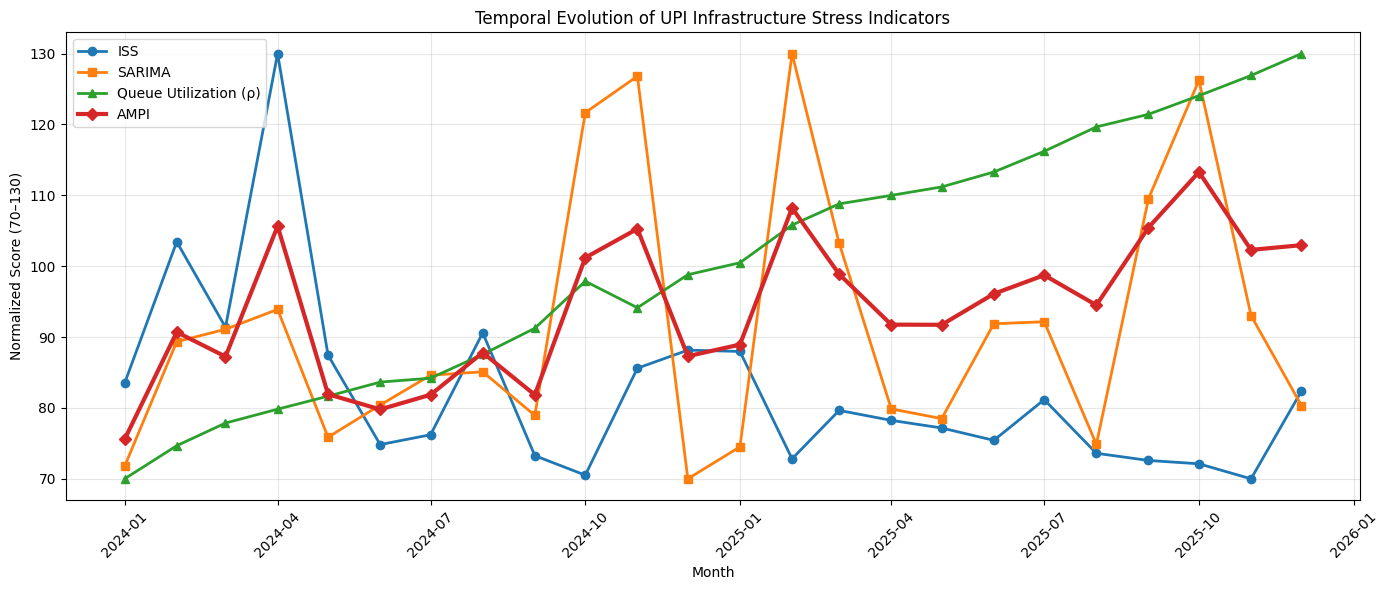

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    merged_df["month"],
    merged_df["iss_mean_norm"],
    marker='o',
    linewidth=2,
    label="ISS"
)

plt.plot(
    merged_df["month"],
    merged_df["sarima_norm"],
    marker='s',
    linewidth=2,
    label="SARIMA"
)

plt.plot(
    merged_df["month"],
    merged_df["rho_norm"],
    marker='^',
    linewidth=2,
    label="Queue Utilization (ρ)"
)

plt.plot(
    merged_df["month"],
    merged_df["AMPI_final"],
    marker='D',
    linewidth=3,
    label="AMPI",
)

plt.title("Temporal Evolution of UPI Infrastructure Stress Indicators")

plt.xlabel("Month")
plt.ylabel("Normalized Score (70–130)")

plt.grid(True, alpha=0.3)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Step 2 – Save publication-quality image

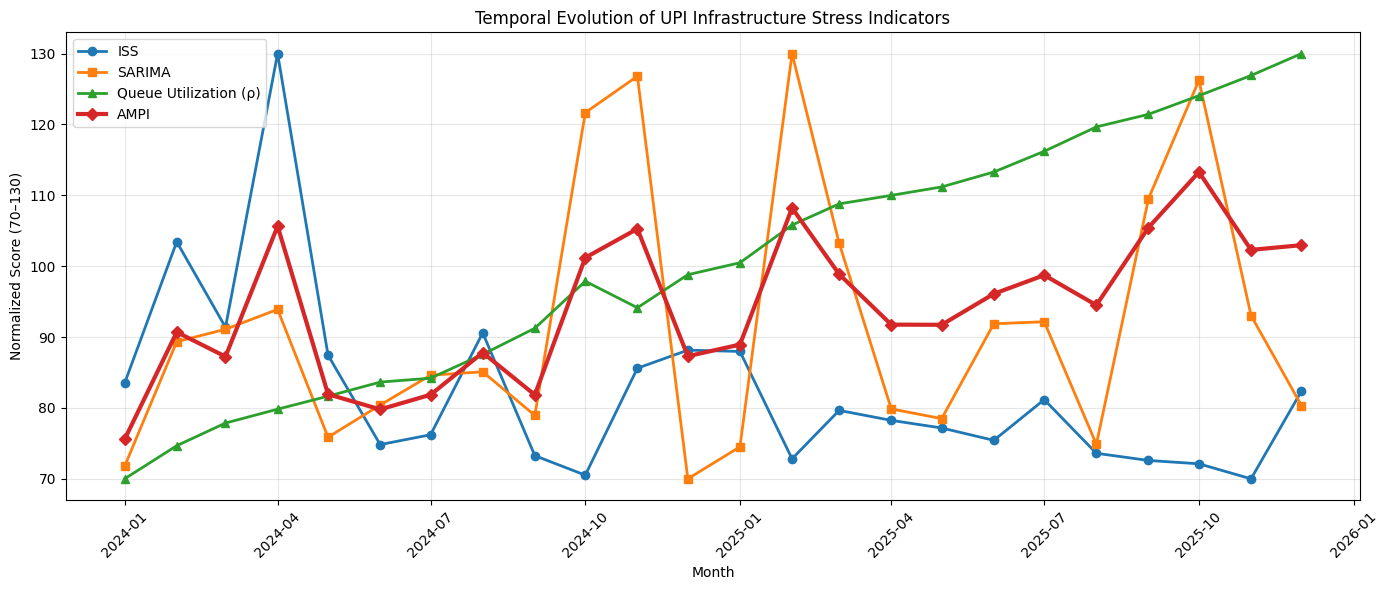

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(merged_df["month"], merged_df["iss_mean_norm"], marker='o', linewidth=2, label="ISS")
plt.plot(merged_df["month"], merged_df["sarima_norm"], marker='s', linewidth=2, label="SARIMA")
plt.plot(merged_df["month"], merged_df["rho_norm"], marker='^', linewidth=2, label="Queue Utilization (ρ)")
plt.plot(merged_df["month"], merged_df["AMPI_final"], marker='D', linewidth=3, label="AMPI")

plt.title("Temporal Evolution of UPI Infrastructure Stress Indicators")

plt.xlabel("Month")
plt.ylabel("Normalized Score (70–130)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure_1_AMPI_Timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
for col in ["iss_mean_norm", "sarima_norm", "rho_norm", "AMPI_final"]:
    idx = merged_df[col].idxmax()
    print(f"\n{col}")
    print(merged_df.loc[idx, ["month", col]])


iss_mean_norm
month            2024-04-01 00:00:00
iss_mean_norm                  130.0
Name: 3, dtype: object

sarima_norm
month          2025-02-01 00:00:00
sarima_norm                  130.0
Name: 13, dtype: object

rho_norm
month       2025-12-01 00:00:00
rho_norm                  130.0
Name: 23, dtype: object

AMPI_final
month         2025-10-01 00:00:00
AMPI_final               113.2902
Name: 21, dtype: object


In [ ]:
for col in ["iss_mean_norm", "sarima_norm", "rho_norm", "AMPI_final"]:
    idx = merged_df[col].idxmin()
    print(f"\n{col}")
    print(merged_df.loc[idx, ["month", col]])


iss_mean_norm
month            2025-11-01 00:00:00
iss_mean_norm                   70.0
Name: 22, dtype: object

sarima_norm
month          2024-12-01 00:00:00
sarima_norm                   70.0
Name: 11, dtype: object

rho_norm
month       2024-01-01 00:00:00
rho_norm                   70.0
Name: 0, dtype: object

AMPI_final
month         2024-01-01 00:00:00
AMPI_final                75.5671
Name: 0, dtype: object


In [ ]:
merged_df[
    [
        "month",
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm",
        "AMPI_final"
    ]
].tail(12).round(4)

,month,iss_mean_norm,sarima_norm,rho_norm,AMPI_final
12,2025-01-01,87.9731,74.5150,100.4908,88.9431
13,2025-02-01,72.8198,130.0000,105.8082,108.2147
14,2025-03-01,79.6518,103.2600,108.7959,98.8784
15,2025-04-01,78.2481,79.8665,109.9942,91.7543
16,2025-05-01,77.1734,78.4949,111.1875,91.7344
17,2025-06-01,75.4284,91.8810,113.2914,96.1027
18,2025-07-01,81.1712,92.1630,116.2163,98.7358
19,2025-08-01,73.6037,74.8654,119.6538,94.5065
20,2025-09-01,72.5910,109.5237,121.4323,105.4555
21,2025-10-01,72.1196,126.2281,124.0599,113.2902


Correlation Analysis

In [ ]:
corr_matrix = merged_df[
    [
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm",
        "AMPI_final"
    ]
].corr()

print(corr_matrix.round(4))

               iss_mean_norm  sarima_norm  rho_norm  AMPI_final
iss_mean_norm         1.0000      -0.1823   -0.5350     -0.0318
sarima_norm          -0.1823       1.0000    0.2373      0.7702
rho_norm             -0.5350       0.2373    1.0000      0.6437
AMPI_final           -0.0318       0.7702    0.6437      1.0000


In [ ]:
print("Correlation with AMPI")
print("-" * 30)

for col in ["iss_mean_norm", "sarima_norm", "rho_norm"]:
    r = merged_df["AMPI_final"].corr(merged_df[col])
    print(f"{col}: {r:.4f}")

Correlation with AMPI
------------------------------
iss_mean_norm: -0.0318
sarima_norm: 0.7702
rho_norm: 0.6437


In [ ]:
print("Confirmed outage months:")
print(
    merged_df.loc[
        merged_df["is_confirmed_outage_month"],
        ["month"]
    ]
)

print("\nDisruption-response months:")
print(
    merged_df.loc[
        merged_df["is_disruption_response_window"],
        ["month"]
    ]
)

Confirmed outage months:
        month
14 2025-03-01
15 2025-04-01

Disruption-response months:
        month
14 2025-03-01
15 2025-04-01
16 2025-05-01


In [ ]:
comparison = (
    merged_df
    .groupby("is_disruption_response_window")[
        [
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm",
            "AMPI_final"
        ]
    ]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)

comparison

iss_mean_norm                       sarima_norm  \
                                       mean    std    min     max        mean   
is_disruption_response_window                                                   
False                                 83.00  13.87  70.00  130.00       92.48   
True                                  78.36   1.24  77.17   79.65       87.21   

                                                    rho_norm               \
                                 std    min     max     mean   std    min   
is_disruption_response_window                                               
False                          19.13  70.00  130.00    99.02  18.8   70.0   
True                           13.92  78.49  103.26   109.99   1.2  108.8   

                                      AMPI_final                        
                                  max       mean    std    min     max  
is_disruption_response_window                                           
False                          130.00      94.13  10.83  75.57  113.29  
True                           111.19      94.12   4.12  91.73   98.88

In [ ]:
comparison2 = (
    merged_df
    .groupby("is_confirmed_outage_month")[
        [
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm",
            "AMPI_final"
        ]
    ]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)

comparison2

iss_mean_norm                       sarima_norm  \
                                   mean    std    min     max        mean   
is_confirmed_outage_month                                                   
False                             82.74  13.59  70.00  130.00       91.85   
True                              78.95   0.99  78.25   79.65       91.56   

                                                rho_norm                \
                             std    min     max     mean    std    min   
is_confirmed_outage_month                                                
False                      18.90  70.00  130.00    99.57  18.53   70.0   
True                       16.54  79.87  103.26   109.40   0.85  108.8   

                                  AMPI_final                        
                              max       mean    std    min     max  
is_confirmed_outage_month                                           
False                      130.00      94.02  10.58  75.57  113.29  
True                       109.99      95.32   5.04  91.75   98.88

In [ ]:
for col in [
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm",
    "AMPI_final"
]:
    print("\n" + "="*50)
    print(f"Top 5 months for {col}")
    print("="*50)

    display(
        merged_df[
            ["month", col]
        ].sort_values(
            by=col,
            ascending=False
        ).head(5)
    )


Top 5 months for iss_mean_norm


,month,iss_mean_norm
3,2024-04-01,130.0000
1,2024-02-01,103.4454
2,2024-03-01,91.3849
7,2024-08-01,90.5955
11,2024-12-01,88.1584



Top 5 months for sarima_norm


,month,sarima_norm
13,2025-02-01,130.0000
10,2024-11-01,126.8137
21,2025-10-01,126.2281
9,2024-10-01,121.6633
20,2025-09-01,109.5237



Top 5 months for rho_norm


,month,rho_norm
23,2025-12-01,130.0000
22,2025-11-01,126.9117
21,2025-10-01,124.0599
20,2025-09-01,121.4323
19,2025-08-01,119.6538



Top 5 months for AMPI_final


,month,AMPI_final
21,2025-10-01,113.2902
13,2025-02-01,108.2147
3,2024-04-01,105.6532
20,2025-09-01,105.4555
10,2024-11-01,105.2736


In [ ]:
final_dataset = merged_df[
    [
        "month",
        "iss_mean_z",
        "iss_max_z",
        "sarima_abs_z",
        "rho",
        "iss_mean_norm",
        "iss_max_norm",   # include since you computed it
        "sarima_norm",
        "rho_norm",
        "AMPI_final"
    ]
]

final_dataset.to_csv("AMPI_Final_Dataset.csv", index=False)